In [1]:
##Load LPS adata

import anndata as ad

adata_lps = ad.read_h5ad("/Users/pdevant/DE_Mac_LPS_anndata.h5ad")
adata_lps



import sys
print(sys.executable)

import anndata, scanpy
print("anndata", anndata.__version__)
print("scanpy", scanpy.__version__)


# Creat Z-score layer

adata_lps.layers["zscore"] = (
    adata_lps.layers["log_fc"] / adata_lps.layers["lfcSE"]
)

adata_lps.layers.keys()

/opt/miniconda3/envs/perturbseq311/bin/python
anndata 0.12.6
scanpy 1.11.5


/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44885/1696939011.py:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata", anndata.__version__)
/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44885/1696939011.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy", scanpy.__version__)


KeysView(Layers with keys: adj_p_value, baseMean, lfcSE, log_fc, p_value, zscore)

In [2]:
# 1) Load Ctrl DE object
adata_ctrl = ad.read_h5ad("DE_Mac_Ctrl_anndata.h5ad")
adata_ctrl
# 2) Make zscore layer
if "zscore" not in adata_ctrl.layers:
    adata_ctrl.layers["zscore"] = adata_ctrl.layers["log_fc"] / adata_ctrl.layers["lfcSE"]

Final gene list size: 32
Removed present (should be empty): set()
Added present?: True
Wrote: metadata/mac_target_gene_list_REGENERATED.xlsx


/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44885/1709093131.py:201: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  signif_matrix.at[gene, gene] = np.nan
/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44885/1709093131.py:201: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  signif_matrix.at[gene, gene] = np.nan
/var/folders/9l/dyp50m2d6s30t17769kjdmt00000gr/T/ipykernel_44885/1709093131.py:201: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  signif

Text(0.5, 1.0, 'Ctrl (LFC z-score)')

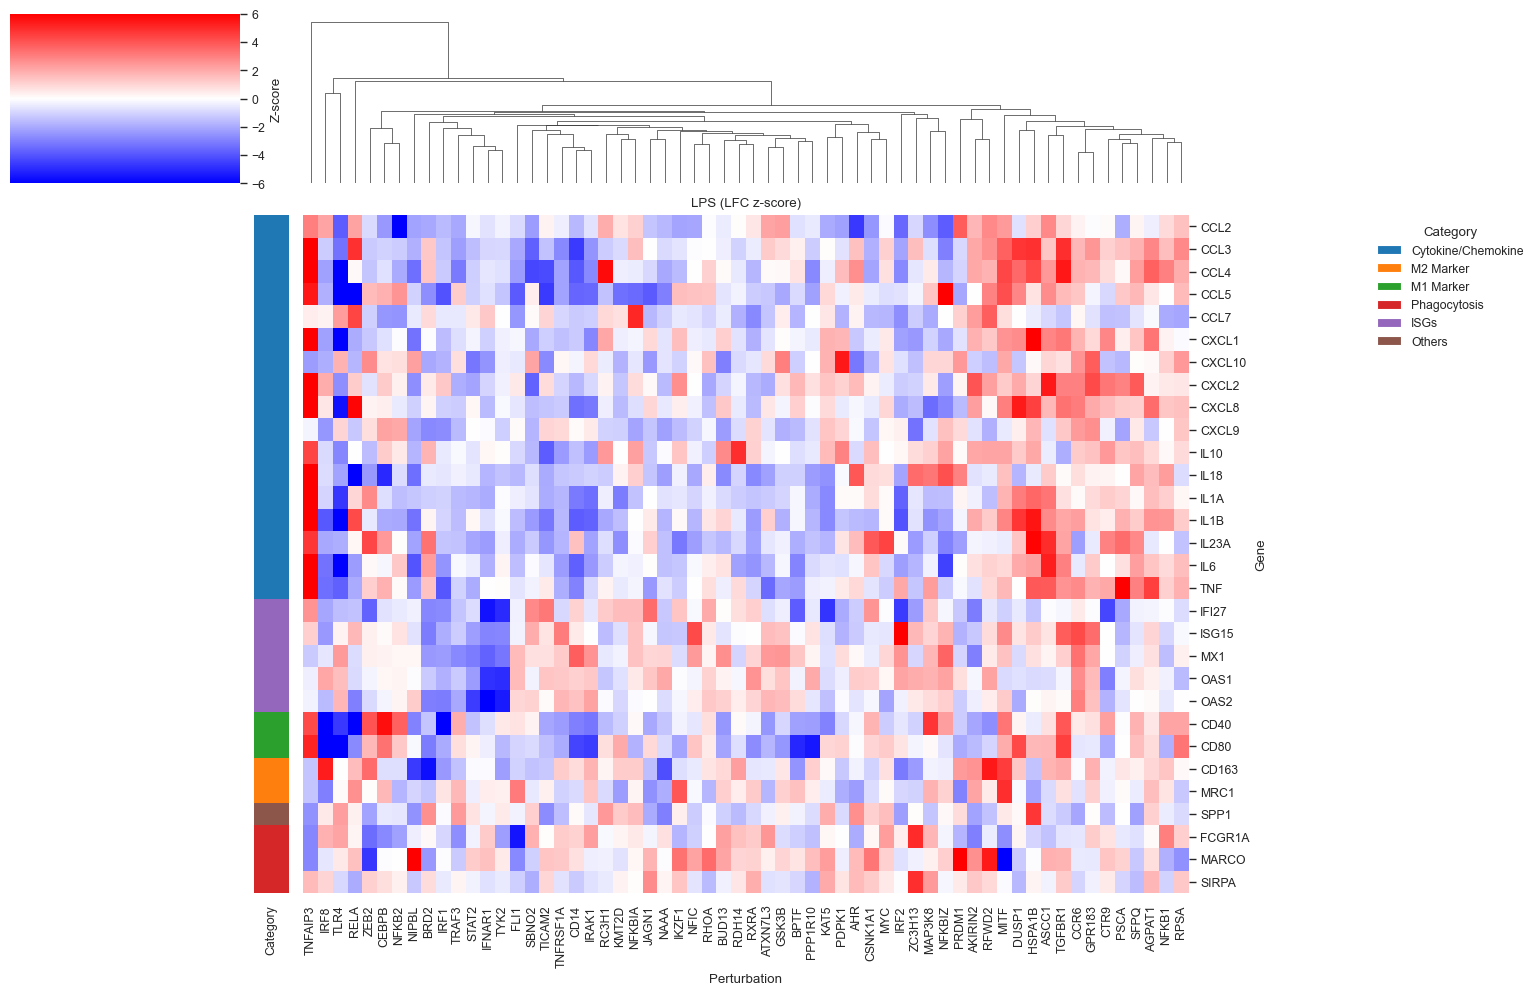

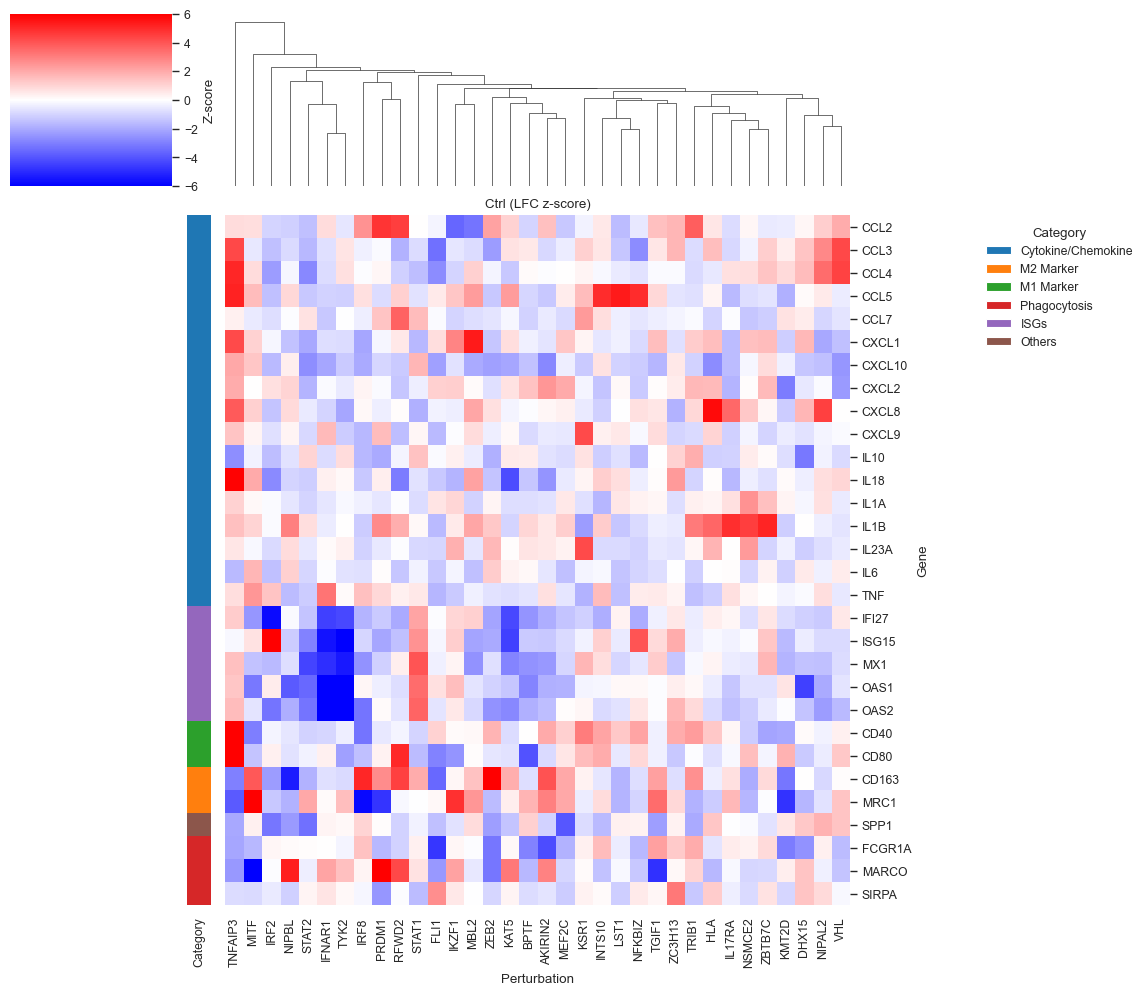

In [6]:
# ==============================
# Initial plot of regulator heatmaps
# ==============================

import os
import numpy as np
import pandas as pd
import anndata
import scanpy as sc

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from typing import List, Union, Optional

sns.set_style("white")
sns.set_context("paper")

# ------------------------------
# 1) Helper: extract DE results in long format
# ------------------------------
def get_DE_results_long(
    adata_de: anndata.AnnData,
    targets: Union[List[str], None] = None,
    genes: Union[List[str], None] = None,
    effect_estimates: Union[str, List[str]] = ["log_fc", "zscore"],
    signif_estimate: Union[None, str] = "adj_p_value",
    signif_alpha: float = 0.1,
    gene_id_col: str = "gene_name",
    target_id_col: str = "contrast",
    target_metadata_cols: List[str] = ["condition", "contrast"],
):
    """
    Extract DE results from AnnData into a long table with columns:
    [index (obs), gene (var_name), log_fc/zscore..., adj_p_value..., significant, gene_name, condition, contrast]
    """
    if isinstance(effect_estimates, str):
        effect_estimates = [effect_estimates]

    # subset obs (targets)
    if targets is not None:
        adata_sub = adata_de[adata_de.obs[target_id_col].isin(targets)].copy()
    else:
        adata_sub = adata_de

    # subset vars (genes)
    if genes is not None:
        # gene_id_col may or may not exist; fall back to var_names if needed
        if gene_id_col in adata_sub.var.columns:
            keep = adata_sub.var[gene_id_col].isin(list(genes))
        else:
            keep = adata_sub.var_names.isin(list(genes))
        adata_sub = adata_sub[:, keep].copy()

    # extract effects
    results = None
    for layer in effect_estimates:
        if layer not in adata_sub.layers:
            continue
        wide = sc.get.obs_df(adata_sub, keys=adata_sub.var_names.tolist(), layer=layer)
        long = wide.melt(ignore_index=False, var_name="gene", value_name=layer).reset_index()
        if results is None:
            results = long
        else:
            results = results.merge(long, on=["index", "gene"], how="outer")

    if results is None:
        results = pd.DataFrame(columns=["index", "gene"] + effect_estimates)

    # add significance
    if signif_estimate is not None and signif_estimate in adata_sub.layers:
        wide_p = sc.get.obs_df(adata_sub, keys=adata_sub.var_names.tolist(), layer=signif_estimate)
        long_p = wide_p.melt(ignore_index=False, var_name="gene", value_name=signif_estimate).reset_index()
        results = results.merge(long_p[["index", "gene", signif_estimate]], on=["index", "gene"], how="left")
        results["significant"] = results[signif_estimate] < signif_alpha
    else:
        results["significant"] = False

    # gene metadata
    if gene_id_col in adata_sub.var.columns:
        gene_meta = adata_sub.var[[gene_id_col]].reset_index().rename(columns={"index": "gene"})
        results = results.merge(gene_meta, on="gene", how="left")
    else:
        results[gene_id_col] = results["gene"]

    # target metadata
    cols = list(dict.fromkeys(target_metadata_cols + [target_id_col]))  # unique, preserve order
    target_meta = adata_sub.obs[cols].reset_index()
    results = results.merge(target_meta, on="index", how="left")

    return results

# ------------------------------
# 2) Make sure zscore exists in your AnnData objects
# ------------------------------
def ensure_zscore(adata):
    if "zscore" not in adata.layers:
        with np.errstate(divide="ignore", invalid="ignore"):
            z = adata.layers["log_fc"] / adata.layers["lfcSE"]
            z = np.where(np.isfinite(z), z, np.nan)
        adata.layers["zscore"] = z

# If you haven't loaded adata_lps/adata_ctrl in this session, uncomment:
# adata_lps = anndata.read_h5ad("DE_Mac_LPS_anndata.h5ad")
# adata_ctrl = anndata.read_h5ad("DE_Mac_Ctrl_anndata.h5ad")

# Ensure gene_name exists
if "gene_name" not in adata_lps.var.columns:
    adata_lps.var["gene_name"] = adata_lps.var_names.astype(str).values
if "gene_name" not in adata_ctrl.var.columns:
    adata_ctrl.var["gene_name"] = adata_ctrl.var_names.astype(str).values

ensure_zscore(adata_lps)
ensure_zscore(adata_ctrl)

# ------------------------------
# 3) Recreate + edit the gene list (no Excel needed)
# ------------------------------
gene_list_df = pd.DataFrame(
    {
        "gene": [
            "TNF","IL1A","IL1B","IL6","IL12A","IL12B","IL18","IL10","IL23A",
            "CCL2","CCL3","CCL4","CCL5","CCL7","CXCL1","CXCL2","CXCL8","CXCL9","CXCL10",
            "IFNB1","IL10","IL1RA",
            "CD80","CD86","CD40",
            "MRC1","CD163",
            "SPP1",
            "ISG15","IFI27","OASL","MX1","RSAD2",
            "SIRPA","FCGR1A","MARCO"
        ],
        "category": [
            "Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine",
            "Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine",
            "Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine",
            "Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine",
            "Cytokine/Chemokine","Cytokine/Chemokine","Cytokine/Chemokine",
            "M1 Marker","M1 Marker","M1 Marker",
            "M2 Marker","M2 Marker",
            "Others",
            "ISGs","ISGs","ISGs","ISGs","ISGs",
            "Phagocytosis","Phagocytosis","Phagocytosis"
        ],
    }
).drop_duplicates(subset=["gene"], keep="first").reset_index(drop=True)

# Apply your requested edits
remove_genes = ["IFNB1", "IL12B", "CD86", "RSAD2", "OASL"]
gene_list_df = gene_list_df[~gene_list_df["gene"].isin(remove_genes)].copy()

add_genes = pd.DataFrame({"gene": ["OAS1", "OAS2"], "category": ["ISGs", "ISGs"]})
gene_list_df = pd.concat([gene_list_df, add_genes], ignore_index=True)
gene_list_df = gene_list_df.drop_duplicates(subset=["gene"], keep="first").reset_index(drop=True)

print("Final gene list size:", gene_list_df.shape[0])
print("Removed present (should be empty):", set(remove_genes) & set(gene_list_df["gene"]))
print("Added present?:", set(["OAS1","OAS2"]) <= set(gene_list_df["gene"]))

# Save regenerated Excel (create folder if needed)
os.makedirs("metadata", exist_ok=True)
out_xlsx = "metadata/mac_target_gene_list_REGENERATED.xlsx"
gene_list_df.to_excel(out_xlsx, index=False)
print("Wrote:", out_xlsx)

gene_categories = gene_list_df.set_index("gene")["category"]

# ------------------------------
# 4) Heatmap function (NO DOTS option)
# ------------------------------
def plot_perturbation_heatmap(
    results_df: pd.DataFrame,
    gene_col: str = "gene_name",
    contrast_col: str = "contrast",
    zscore_col: str = "zscore",
    signif_col: str = "significant",
    row_annotations: Optional[pd.Series] = None,
    figsize: Optional[tuple] = None,
    vmin: Optional[float] = None,
    vmax: Optional[float] = None,
    show_dots: bool = False,     # default NO DOTS
    dot_size: float = 12,
    row_cluster: bool = True,
    row_order: Optional[List[str]] = None,
    col_order: Optional[List[str]] = None,
    filter_to_signif_perts: bool = True,  # keep original behavior unless you change it
    **kwargs
):
    if row_order is not None:
        row_cluster = False
    _col_cluster = kwargs.pop("col_cluster", True) and (col_order is None)

    zscore_matrix = results_df.pivot_table(
        index=gene_col, columns=contrast_col, values=zscore_col, aggfunc="first"
    )
    signif_matrix = results_df.pivot_table(
        index=gene_col, columns=contrast_col, values=signif_col, aggfunc="first"
    )

    # mask self-target effects if names match
    for gene in signif_matrix.index:
        if gene in signif_matrix.columns:
            signif_matrix.at[gene, gene] = np.nan
            if gene in zscore_matrix.columns:
                zscore_matrix.at[gene, gene] = np.nan

    # optionally filter perturbations with >=1 significant gene
    if filter_to_signif_perts:
        has_signif = signif_matrix.any(axis=0)
        zscore_plot = zscore_matrix.loc[:, has_signif]
        signif_plot = signif_matrix.loc[:, has_signif]
    else:
        zscore_plot = zscore_matrix
        signif_plot = signif_matrix

    # row colors
    row_colors = None
    category_palette = None
    annot = None
    if row_annotations is not None:
        annot = row_annotations.reindex(zscore_plot.index)
        cats = annot.dropna().unique()
        palette = dict(zip(cats, sns.color_palette("tab10", len(cats))))
        row_colors = annot.map(palette).rename("Category")
        category_palette = palette

    # ordering
    if row_order is not None:
        zscore_plot = zscore_plot.reindex(row_order)
        signif_plot = signif_plot.reindex(row_order)
        if row_colors is not None:
            row_colors = row_colors.reindex(row_order)
    elif not row_cluster and annot is not None:
        tmp = pd.DataFrame({"category": annot, "gene": annot.index}).reset_index(drop=True)
        tmp = tmp.sort_values(["category", "gene"], kind="stable")
        gene_order = tmp["gene"].tolist()
        zscore_plot = zscore_plot.reindex(gene_order)
        signif_plot = signif_plot.reindex(gene_order)
        if row_colors is not None:
            row_colors = row_colors.reindex(gene_order)

    if col_order is not None:
        zscore_plot = zscore_plot.reindex(columns=col_order)
        signif_plot = signif_plot.reindex(columns=col_order)

    if figsize is None:
        figsize = (max(10, zscore_plot.shape[1] * 0.35), max(6, zscore_plot.shape[0] * 0.4))

    cg = sns.clustermap(
        zscore_plot,
        cmap="bwr",
        center=0,
        vmin=vmin,
        vmax=vmax,
        linewidths=0,
        cbar_kws={"label": "Z-score"},
        row_colors=row_colors,
        figsize=figsize,
        row_cluster=row_cluster,
        col_cluster=_col_cluster,
        **kwargs
    )

    # Optional dots (off by default)
    if show_dots:
        _row_idx = cg.dendrogram_row.reordered_ind if row_cluster else np.arange(zscore_plot.shape[0])
        _col_idx = cg.dendrogram_col.reordered_ind if _col_cluster else np.arange(zscore_plot.shape[1])
        signif_reordered = signif_plot.iloc[_row_idx, _col_idx]
        for i in range(signif_reordered.shape[0]):
            for j in range(signif_reordered.shape[1]):
                if bool(signif_reordered.iloc[i, j]):
                    cg.ax_heatmap.scatter(j + 0.5, i + 0.5, color="black", s=dot_size, zorder=2)

    if category_palette is not None:
        handles = [matplotlib.patches.Patch(facecolor=c, label=l) for l, c in category_palette.items()]
        cg.ax_heatmap.legend(handles=handles, title="Category",
                             bbox_to_anchor=(1.2, 1), loc="upper left", frameon=False)

    cg.ax_heatmap.set_xlabel("Perturbation")
    cg.ax_heatmap.set_ylabel("Gene")
    plt.tight_layout()
    return cg.fig, cg.ax_heatmap, zscore_plot

# ------------------------------
# 5) Compute long DE tables for updated gene list
# ------------------------------
gene_list_effects_lps = get_DE_results_long(adata_lps, genes=gene_list_df["gene"])
gene_list_effects_ctrl = get_DE_results_long(adata_ctrl, genes=gene_list_df["gene"])

# ------------------------------
# 6) Plot 
# ------------------------------
vmin, vmax = -6, 6  # adjust for paper consistency if you want

fig, ax, _ = plot_perturbation_heatmap(
    gene_list_effects_lps,
    row_annotations=gene_categories,
    row_cluster=False,
    xticklabels=True,
    figsize=(16, 10),
    vmin=vmin, vmax=vmax,
    show_dots=False,
    filter_to_signif_perts=True,
)
ax.set_title("LPS (LFC z-score)")

fig, ax, _ = plot_perturbation_heatmap(
    gene_list_effects_ctrl,
    row_annotations=gene_categories,
    row_cluster=False,
    xticklabels=True,
    figsize=(12, 10),
    vmin=vmin, vmax=vmax,
    show_dots=False,
    filter_to_signif_perts=True,
)
ax.set_title("Ctrl (LFC z-score)")